# Experimentos: MLP no MNIST

Após validar a implementação da rede neural no problema XOR, o próximo passo é aplicá-la a um conjunto de dados mais complexo: o MNIST.

O MNIST é um dos datasets mais utilizados para estudos de aprendizado de máquina e visão computacional. Ele contém imagens de dígitos manuscritos de 0 a 9, representados por imagens em escala de cinza com resolução de 28 × 28 pixels.

O conjunto de dados é composto por 60.000 exemplos para treinamento e 10.000 exemplos para teste, permitindo avaliar a capacidade de generalização do modelo em um problema de classificação multiclasse.

Embora os princípios fundamentais permaneçam os mesmos utilizados no XOR (forward pass, cálculo da função de perda, backpropagation e atualização dos pesos) serão necessárias algumas adaptações para lidar com o maior volume de dados e com a classificação de múltiplas classes.

Nas etapas a seguir serão apresentadas essas modificações e sua implementação.

## Etapa 1: Carregar o MNIST

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Carrega o MNIST
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Treino:", X_train.shape, y_train.shape)
print("Teste: ", X_test.shape, y_test.shape)
print("Valores de pixel: min =", X_train.min(), "max =", X_train.max())

I0000 00:00:1781134431.696815   87017 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781134431.697169   87017 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781134431.770398   87017 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781134432.842606   87017 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Treino: (60000, 28, 28) (60000,)
Teste:  (10000, 28, 28) (10000,)
Valores de pixel: min = 0 max = 255


## Etapa 2: Pré-processamento

Antes do treinamento da rede neural, é necessário realizar algumas transformações nos dados para adequá-los à arquitetura da MLP.

Os dados brutos apresentam dois desafios principais:

1. **Shape:** as imagens possuem dimensão `(28, 28)`, mas a rede recebe vetores como entrada. Por isso, cada imagem precisa ser convertida para um vetor de 784 atributos (`28 × 28 = 784`).

2. **Escala:** os valores dos pixels variam de 0 a 255. Para facilitar o treinamento e melhorar a estabilidade dos cálculos, os dados são normalizados para o intervalo de 0 a 1.

Além disso, os rótulos são convertidos para o formato **One-Hot Encoding**. Nesse formato, cada dígito é representado por um vetor de tamanho 10 contendo valor 1 apenas na posição correspondente à classe correta.

Por exemplo:

`3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

Essa representação será utilizada posteriormente no cálculo da função de perda para classificação multiclasse.

In [4]:
# 1. Achatar: (60000, 28, 28) → (60000, 784)
X_train_flat = X_train.reshape(60000, -1)
X_test_flat  = X_test.reshape(10000, -1)

# 2. Normalizar: 0-255 → 0-1
X_train_flat = X_train_flat / 255.0
X_test_flat  = X_test_flat  / 255.0

# 3. One-hot encoding dos labels
def one_hot(y, num_classes=10):
    n = len(y)
    oh = np.zeros((n, num_classes))
    oh[np.arange(n), y] = 1
    return oh

y_train_oh = one_hot(y_train)
y_test_oh  = one_hot(y_test)

print("X_train:", X_train_flat.shape)
print("X_test: ", X_test_flat.shape)
print("y_train:", y_train_oh.shape)
print("\nExemplo label original:", y_train[0])
print("Exemplo one-hot:       ", y_train_oh[0])

X_train: (60000, 784)
X_test:  (10000, 784)
y_train: (60000, 10)

Exemplo label original: 5
Exemplo one-hot:        [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Etapa 3: Funções de Ativação

No problema XOR foi utilizada a função Sigmoid em todas as camadas da rede. Entretanto, para o MNIST, essa escolha não é a mais adequada devido à maior quantidade de dados e parâmetros envolvidos no treinamento.

Nas camadas ocultas será utilizada a função **ReLU (Rectified Linear Unit)**, definida como:

$f(x) = max(0, x)$

A ReLU é uma das funções de ativação mais utilizadas em redes neurais modernas por ser simples de calcular e reduzir problemas relacionados ao desaparecimento dos gradientes (vanishing gradient), comuns quando se utiliza Sigmoid em redes maiores. Sua derivada também é simples, assumindo valor 1 para entradas positivas e 0 para entradas negativas.

Na camada de saída será utilizada a função **Softmax**. Diferentemente da Sigmoid, que produz uma única probabilidade, a Softmax transforma os valores de saída da rede em uma distribuição de probabilidades sobre as 10 classes do MNIST (dígitos de 0 a 9).

Dessa forma, cada neurônio da camada de saída representa a probabilidade da imagem pertencer a uma determinada classe, e a soma de todas as probabilidades é igual a 1.

A Softmax será utilizada em conjunto com a função de perda Categorical Cross-Entropy, combinação amplamente empregada em problemas de classificação multiclasse.

Uma vantagem importante da combinação Softmax + Categorical Cross-Entropy é que ela produz uma simplificação matemática durante o cálculo dos gradientes, tornando o backpropagation mais eficiente. Essa simplificação será apresentada na etapa de cálculo da função de perda.

In [5]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    # subtrai o máximo por estabilidade numérica
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

# Testes rápidos
test = np.array([-2, -1, 0, 1, 2], dtype=float)
print("ReLU:           ", relu(test))
print("ReLU derivada:  ", relu_derivative(test))

logits = np.array([[2.0, 1.0, 0.1]])
probs  = softmax(logits)
print("\nSoftmax entrada:", logits)
print("Softmax saída:  ", probs.round(4))
print("Soma:           ", probs.sum())

ReLU:            [0. 0. 0. 1. 2.]
ReLU derivada:   [0. 0. 0. 1. 1.]

Softmax entrada: [[2.  1.  0.1]]
Softmax saída:   [[0.659  0.2424 0.0986]]
Soma:            1.0


## Etapa 4: Forward Pass

Com os dados preparados, podemos definir a arquitetura inicial da MLP utilizada para o MNIST.

Arquitetura escolhida:

784 → 128 → 64 → 10

onde:

- 784 neurônios de entrada correspondem aos pixels da imagem (28 × 28);
- 128 e 64 neurônios formam as camadas ocultas;
- 10 neurônios de saída representam os dígitos de 0 a 9.

Nas camadas ocultas é utilizada a função de ativação ReLU, enquanto a camada de saída utiliza Softmax para produzir uma distribuição de probabilidades entre as 10 classes.

Assim como no XOR, durante o forward pass são armazenados os valores de pré-ativação (z) e ativação (a) de cada camada. Essas informações serão necessárias posteriormente para o cálculo dos gradientes durante o backpropagation.

Para inicializar os pesos foi utilizada a Inicialização de He, recomendada para redes que utilizam ReLU. Essa técnica ajuda a manter a escala das ativações ao longo das camadas, favorecendo a estabilidade do treinamento.

In [6]:
def forward_mnist(X, params):
    W1, b1, W2, b2, W3, b3 = params
    
    # Camada oculta 1
    z1 = X @ W1 + b1
    a1 = relu(z1)
    
    # Camada oculta 2
    z2 = a1 @ W2 + b2
    a2 = relu(z2)
    
    # Camada de saída
    z3 = a2 @ W3 + b3
    a3 = softmax(z3)
    
    cache = (z1, a1, z2, a2, z3, a3)
    return a3, cache

def init_params(seed=42):
    np.random.seed(seed)
    # He initialization: melhor que 0.1 fixo pra ReLU
    W1 = np.random.randn(784, 128) * np.sqrt(2 / 784)
    b1 = np.zeros((1, 128))
    W2 = np.random.randn(128, 64) * np.sqrt(2 / 128)
    b2 = np.zeros((1, 64))
    W3 = np.random.randn(64, 10) * np.sqrt(2 / 64)
    b3 = np.zeros((1, 10))
    return [W1, b1, W2, b2, W3, b3]

params = init_params()
W1, b1, W2, b2, W3, b3 = params

# Testa com 5 exemplos
a3, cache = forward_mnist(X_train_flat[:5], params)
print("Shape saída:", a3.shape)
print("Predições (primeiros 5 exemplos):")
print(a3.round(3))
print("\nSoma de cada linha (deve ser 1.0):")
print(a3.sum(axis=1))

Shape saída: (5, 10)
Predições (primeiros 5 exemplos):
[[0.094 0.109 0.088 0.167 0.086 0.144 0.087 0.067 0.082 0.075]
 [0.038 0.095 0.204 0.167 0.066 0.089 0.168 0.09  0.037 0.047]
 [0.15  0.063 0.104 0.114 0.125 0.096 0.115 0.101 0.068 0.063]
 [0.08  0.075 0.168 0.138 0.127 0.095 0.086 0.105 0.067 0.06 ]
 [0.134 0.088 0.062 0.109 0.146 0.113 0.059 0.138 0.064 0.086]]

Soma de cada linha (deve ser 1.0):
[1. 1. 1. 1. 1.]


## Etapa 5: Função de perda e Backpropagation

Como o MNIST é um problema de classificação multiclasse, utilizamos a função de perda Categorical Cross-Entropy.

Essa função compara as probabilidades previstas pela rede com a classe correta representada em formato One-Hot Encoding. Quanto maior a probabilidade atribuída à classe correta, menor será a perda.

A função é definida por:

$$L = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{10} y_{ij} \log(\hat{y}_{ij})$$

onde:

- y representa os valores reais (one-hot);
- ŷ representa as probabilidades produzidas pela Softmax;
- n representa a quantidade de exemplos.

Uma vantagem importante dessa combinação é que a derivada da Softmax combinada com a Categorical Cross-Entropy simplifica para:

$\frac{\partial L}{\partial z_3} = \hat{y} - y$

Ou seja, o gradiente da camada de saída corresponde apenas à diferença entre as probabilidades previstas pela rede e os valores esperados. Essa simplificação reduz a complexidade do cálculo do backpropagation e torna a implementação mais eficiente.

In [7]:
def categorical_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

def backward_mnist(X, y_true, params, cache):
    W1, b1, W2, b2, W3, b3 = params
    z1, a1, z2, a2, z3, a3 = cache
    n = X.shape[0]
    
    # Camada de saída: derivada simplificada softmax + cross-entropy
    dz3 = (a3 - y_true) / n
    dW3 = a2.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)
    
    # Camada oculta 2
    da2 = dz3 @ W3.T
    dz2 = da2 * relu_derivative(z2)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    
    # Camada oculta 1
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_derivative(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    
    grads = [dW1, db1, dW2, db2, dW3, db3]
    return grads

def update_params(params, grads, lr):
    return [p - lr * g for p, g in zip(params, grads)]

# Teste
a3_test, cache_test = forward_mnist(X_train_flat[:32], params)
loss_test = categorical_cross_entropy(y_train_oh[:32], a3_test)
grads_test = backward_mnist(X_train_flat[:32], y_train_oh[:32], params, cache_test)

print("Loss inicial:", round(loss_test, 4))
print("Shapes dos gradientes:")
for i, g in enumerate(grads_test):
    print(f"  grad[{i}]: {g.shape}")

Loss inicial: 2.4041
Shapes dos gradientes:
  grad[0]: (784, 128)
  grad[1]: (1, 128)
  grad[2]: (128, 64)
  grad[3]: (1, 64)
  grad[4]: (64, 10)
  grad[5]: (1, 10)


## Etapa 6: Treinamento com Mini-Batches

No XOR, todos os exemplos eram processados simultaneamente durante cada atualização dos pesos. No entanto, essa abordagem não é prática para o MNIST, que possui 60.000 imagens de treinamento.

Por isso, utilizou-se a técnica de **mini-batches**, na qual os dados são divididos em pequenos grupos e a rede é atualizada após processar cada grupo.

Essa abordagem apresenta algumas vantagens:

- Reduz o consumo de memória em comparação ao uso de todo o dataset de uma vez;
- Realiza várias atualizações dos pesos durante cada época, acelerando o aprendizado;
- Produz gradientes mais estáveis do que o treinamento utilizando apenas um exemplo por vez.

Uma época corresponde ao processamento de todos os mini-batches do conjunto de treinamento. Com 60.000 exemplos e batch size igual a 64, são realizadas aproximadamente 937 atualizações dos pesos por época.

In [8]:
def train(X, y, epochs=10, lr=0.1, batch_size=64, seed=42):
    params = init_params(seed)
    loss_history = []
    acc_history = []
    
    n = X.shape[0]
    
    for epoch in range(epochs):
        # Embaralha os dados a cada época
        idx = np.random.permutation(n)
        X_shuf = X[idx]
        y_shuf = y[idx]
        
        epoch_loss = 0
        num_batches = 0
        
        # Mini-batches
        for i in range(0, n, batch_size):
            X_batch = X_shuf[i:i+batch_size]
            y_batch = y_shuf[i:i+batch_size]
            
            # Forward
            a3, cache = forward_mnist(X_batch, params)
            
            # Loss
            loss = categorical_cross_entropy(y_batch, a3)
            epoch_loss += loss
            num_batches += 1
            
            # Backward
            grads = backward_mnist(X_batch, y_batch, params, cache)
            
            # Atualiza
            params = update_params(params, grads, lr)
        
        # Métricas da época
        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)
        
        # Acurácia no treino
        a3_full, _ = forward_mnist(X, params)
        preds = np.argmax(a3_full, axis=1)
        labels = np.argmax(y, axis=1)
        acc = np.mean(preds == labels)
        acc_history.append(acc)
        
        print(f"Época {epoch+1:2d} | Loss: {avg_loss:.4f} | Acurácia treino: {acc*100:.1f}%")
    
    return params, loss_history, acc_history

# Treina por 10 épocas
params, loss_history, acc_history = train(
    X_train_flat, y_train_oh,
    epochs=10, lr=0.1, batch_size=64
)

Época  1 | Loss: 0.3317 | Acurácia treino: 95.0%
Época  2 | Loss: 0.1496 | Acurácia treino: 96.3%
Época  3 | Loss: 0.1080 | Acurácia treino: 97.0%
Época  4 | Loss: 0.0856 | Acurácia treino: 97.4%
Época  5 | Loss: 0.0706 | Acurácia treino: 98.3%
Época  6 | Loss: 0.0582 | Acurácia treino: 98.7%
Época  7 | Loss: 0.0492 | Acurácia treino: 98.9%
Época  8 | Loss: 0.0418 | Acurácia treino: 99.2%
Época  9 | Loss: 0.0355 | Acurácia treino: 98.4%
Época 10 | Loss: 0.0313 | Acurácia treino: 99.3%


## Etapa 7: Experimento 1

O primeiro experimento foi realizado utilizando a arquitetura definida nas etapas anteriores, composta por duas camadas ocultas com 128 e 64 neurônios. O objetivo foi verificar se a implementação da MLP era capaz de aprender adequadamente o conjunto de dados MNIST e atingir a meta mínima de desempenho estabelecida para a atividade.

Para o treinamento foram utilizadas 10 épocas, learning rate igual a 0,1 e mini-batches de 64 exemplos.

In [10]:
# Avalia no conjunto de teste
a3_test, _ = forward_mnist(X_test_flat, params)
preds_test = np.argmax(a3_test, axis=1)
acc_test = np.mean(preds_test == y_test)

print(f"Acurácia no teste: {acc_test*100:.2f}%")

Acurácia no teste: 97.79%


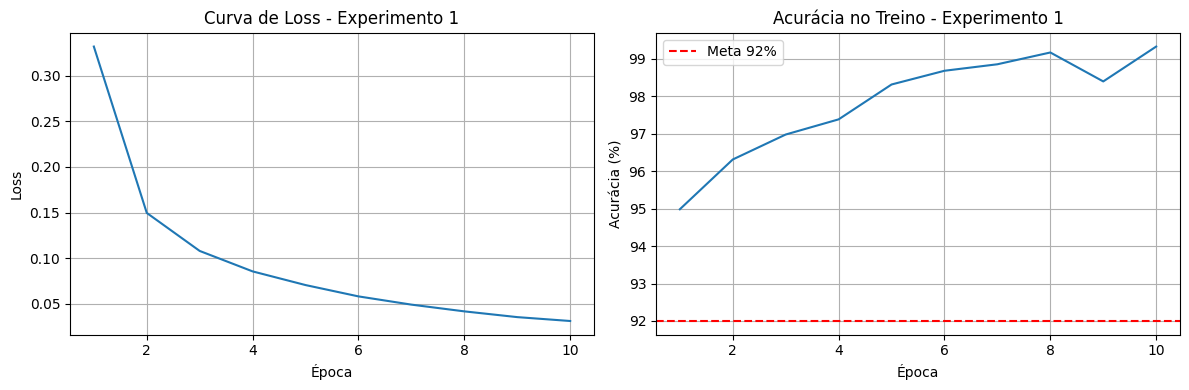

Salvo em results/exp1_curves.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, 11), loss_history)
ax1.set_title("Curva de Loss - Experimento 1")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(range(1, 11), [a*100 for a in acc_history])
ax2.axhline(y=92, color='r', linestyle='--', label='Meta 92%')
ax2.set_title("Acurácia no Treino - Experimento 1")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia (%)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("../results/exp1_curves.png", dpi=150)
plt.show()

print("Salvo em results/exp1_curves.png")

Observa-se que a função de perda diminuiu continuamente ao longo do treinamento, enquanto a acurácia aumentou até atingir aproximadamente 99,3% no conjunto de treino.

Ao avaliar o modelo no conjunto de teste, foi obtida acurácia de 97,79%, valor superior à meta mínima de 92%. Esse resultado indica que a rede foi capaz de aprender padrões relevantes dos dígitos manuscritos e generalizar adequadamente para exemplos não vistos.

## Etapa 8: Experimento 2

Após validar a configuração inicial, foi realizado um segundo experimento para analisar o impacto da redução da capacidade da rede e da diminuição do learning rate.

Para isso, a arquitetura foi alterada para 784 → 64 → 32 → 10 e o learning rate foi reduzido para 0,01. A expectativa era que essa configuração apresentasse aprendizado mais lento e desempenho inferior ao experimento anterior.

In [12]:
def init_params_exp2(seed=42):
    np.random.seed(seed)
    W1 = np.random.randn(784, 64) * np.sqrt(2 / 784)
    b1 = np.zeros((1, 64))
    W2 = np.random.randn(64, 32) * np.sqrt(2 / 64)
    b2 = np.zeros((1, 32))
    W3 = np.random.randn(32, 10) * np.sqrt(2 / 32)
    b3 = np.zeros((1, 10))
    return [W1, b1, W2, b2, W3, b3]

def forward_exp2(X, params):
    W1, b1, W2, b2, W3, b3 = params
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = relu(z2)
    z3 = a2 @ W3 + b3
    a3 = softmax(z3)
    cache = (z1, a1, z2, a2, z3, a3)
    return a3, cache

def backward_exp2(X, y_true, params, cache):
    W1, b1, W2, b2, W3, b3 = params
    z1, a1, z2, a2, z3, a3 = cache
    n = X.shape[0]
    
    dz3 = (a3 - y_true) / n
    dW3 = a2.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)
    
    da2 = dz3 @ W3.T
    dz2 = da2 * relu_derivative(z2)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_derivative(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    
    return [dW1, db1, dW2, db2, dW3, db3]

# Treina experimento 2
params2 = init_params_exp2()
loss_history2 = []
acc_history2 = []
lr2 = 0.01
batch_size = 64
n = X_train_flat.shape[0]

for epoch in range(10):
    idx = np.random.permutation(n)
    X_shuf = X_train_flat[idx]
    y_shuf = y_train_oh[idx]
    
    epoch_loss = 0
    num_batches = 0
    
    for i in range(0, n, batch_size):
        X_batch = X_shuf[i:i+batch_size]
        y_batch = y_shuf[i:i+batch_size]
        
        a3, cache = forward_exp2(X_batch, params2)
        loss = categorical_cross_entropy(y_batch, a3)
        epoch_loss += loss
        num_batches += 1
        
        grads = backward_exp2(X_batch, y_batch, params2, cache)
        params2 = update_params(params2, grads, lr2)
    
    avg_loss = epoch_loss / num_batches
    loss_history2.append(avg_loss)
    
    a3_full, _ = forward_exp2(X_train_flat, params2)
    preds = np.argmax(a3_full, axis=1)
    acc = np.mean(preds == y_train)
    acc_history2.append(acc)
    
    print(f"Época {epoch+1:2d} | Loss: {avg_loss:.4f} | Acurácia treino: {acc*100:.1f}%")

# Avalia no teste
a3_test2, _ = forward_exp2(X_test_flat, params2)
preds_test2 = np.argmax(a3_test2, axis=1)
acc_test2 = np.mean(preds_test2 == y_test)
print(f"\nAcurácia no teste: {acc_test2*100:.2f}%")

Época  1 | Loss: 0.9191 | Acurácia treino: 88.2%
Época  2 | Loss: 0.3698 | Acurácia treino: 90.4%
Época  3 | Loss: 0.3088 | Acurácia treino: 91.8%
Época  4 | Loss: 0.2761 | Acurácia treino: 92.5%
Época  5 | Loss: 0.2530 | Acurácia treino: 93.1%
Época  6 | Loss: 0.2350 | Acurácia treino: 93.5%
Época  7 | Loss: 0.2193 | Acurácia treino: 94.0%
Época  8 | Loss: 0.2068 | Acurácia treino: 94.4%
Época  9 | Loss: 0.1951 | Acurácia treino: 94.7%
Época 10 | Loss: 0.1847 | Acurácia treino: 95.0%

Acurácia no teste: 94.73%


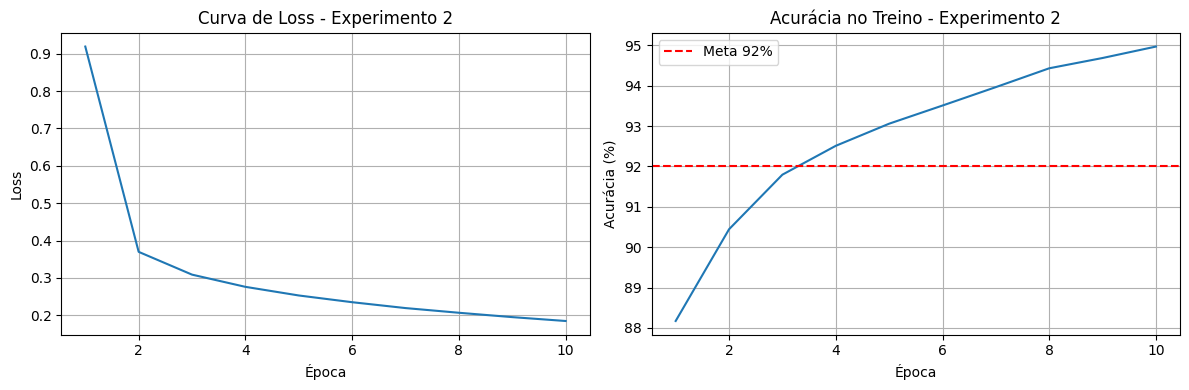

In [14]:
# Plot do experimento 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, 11), loss_history2)
ax1.set_title("Curva de Loss - Experimento 2")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(range(1, 11), [a*100 for a in acc_history2])
ax2.axhline(y=92, color='r', linestyle='--', label='Meta 92%')
ax2.set_title("Acurácia no Treino - Experimento 2")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia (%)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("../results/exp2_curves.png", dpi=150)
plt.show()

Os resultados confirmaram a hipótese inicial. Embora o modelo tenha alcançado desempenho satisfatório, sua acurácia final foi inferior à obtida no experimento 1.

Além disso, a curva de perda indica que o treinamento ainda apresentava tendência de melhora ao final da décima época, sugerindo que mais épocas poderiam ser necessárias para alcançar a convergência.

## Etapa 9: Análise comparativa

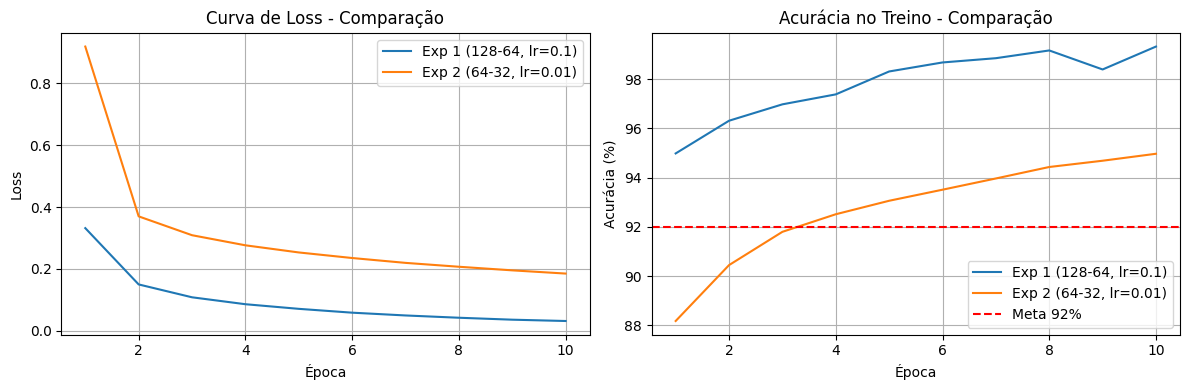

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, 11), loss_history, label='Exp 1 (128-64, lr=0.1)')
ax1.plot(range(1, 11), loss_history2, label='Exp 2 (64-32, lr=0.01)')
ax1.set_title("Curva de Loss - Comparação")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, 11), [a*100 for a in acc_history], label='Exp 1 (128-64, lr=0.1)')
ax2.plot(range(1, 11), [a*100 for a in acc_history2], label='Exp 2 (64-32, lr=0.01)')
ax2.axhline(y=92, color='r', linestyle='--', label='Meta 92%')
ax2.set_title("Acurácia no Treino - Comparação")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia (%)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("../results/comparacao_experimentos.png", dpi=150)
plt.show()

| | Experimento 1 | Experimento 2 |
|---|---|---|
| Arquitetura | 784→128→64→10 | 784→64→32→10 |
| Learning rate | 0.1 | 0.01 |
| Acurácia treino | 99.3% | 95.0% |
| Acurácia teste | 97.79% | 94.73% |
| Loss época 10 | 0.0313 | 0.1847 |

Os dois experimentos atingiram a meta mínima de 92% de acurácia no conjunto de teste. Entretanto, a configuração utilizada no experimento 1 apresentou melhor desempenho geral, alcançando maior acurácia e menor valor de loss.

Como dois hiperparâmetros foram alterados simultaneamente no experimento 2 (arquitetura e learning rate), não é possível determinar individualmente qual deles teve maior impacto no resultado. Ainda assim, os experimentos evidenciam que a escolha dos hiperparâmetros influencia diretamente a velocidade de convergência e a capacidade de generalização da rede neural.

## Conclusão

Neste trabalho foi implementada uma rede neural do tipo Multi-Layer Perceptron utilizando apenas NumPy. A implementação foi inicialmente validada no problema XOR e posteriormente adaptada para a classificação de dígitos manuscritos do conjunto de dados MNIST.

Os resultados demonstraram que a rede foi capaz de aprender o problema proposto e superar a meta mínima de desempenho estabelecida para a atividade. Além disso, os experimentos realizados permitiram observar como alterações na arquitetura e nos hiperparâmetros influenciam o comportamento do treinamento.

Dessa forma, os objetivos da atividade foram alcançados, validando tanto a implementação da MLP quanto sua aplicação em um problema real de classificação multiclasse.